In [9]:
"""
Script per generare grafici aggiuntivi di analisi per Federated Learning con EigenLayer
Configurazioni: 5, 10, 20, 30, 50 clients
Output: PDF
"""

import json
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# CONFIGURAZIONE
# ============================================================================

# Path ai file JSON (modifica questi path se necessario)
FILES = {
    5: "experimental_results_5_clients.json",
    10: "experimental_results_10_clients.json",
    20: "experimental_results_20_clients.json",
    30: "experimental_results_30_clients.json",
    50: "experimental_results_50_clients.json"
}

# Directory di output
OUTPUT_DIR = Path("images")

# ============================================================================
# CARICAMENTO DATI
# ============================================================================

def load_data(files):
    """Carica i dati da tutti i file JSON"""
    data = {}
    for num_clients, filepath in files.items():
        try:
            with open(filepath, 'r') as f:
                data[num_clients] = json.load(f)
            print(f"✓ Caricato: {filepath}")
        except FileNotFoundError:
            print(f"✗ File non trovato: {filepath}")
            return None
    return data

# ============================================================================
# GRAFICO 3: Total Cost Breakdown (Grouped Bar)
# ============================================================================

def create_cost_breakdown_graph(data, output_dir):
    """
    Grouped bar chart con breakdown di training time, validation time e gas cost
    """
    num_clients_list = sorted(data.keys())
    training_times = []
    validation_times = []
    gas_costs_millions = []
    
    for n in num_clients_list:
        training_times.append(data[n]['training_time_total'])
        validation_times.append(data[n]['validation_time_total'])
        
        clients_data = data[n]['clients']
        total_gas = sum(client['gas_script'] for client in clients_data)
        gas_costs_millions.append(total_gas / 1_000_000)
    
    # Crea il grafico con due assi Y
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    x = range(len(num_clients_list))
    width = 0.25
    
    # Barre affiancate per i tempi (COLORI ORIGINALI)
    ax1.bar(
        [i - width for i in x],
        training_times,
        width,
        label='Model Training Time',
        color='g',
        alpha=0.7
    )
    ax1.bar(
        x,
        validation_times,
        width,
        label='On-Chain Validation Time',
        color='b',
        alpha=0.7
    )
    
    # Asse X e Y sinistro
    ax1.set_xlabel('Number of Participants', fontsize=17)
    ax1.set_ylabel('Time (seconds)', fontsize=17)
    ax1.set_xticks(x)
    ax1.set_xticklabels(num_clients_list, fontsize=12)
    ax1.tick_params(axis='y', labelsize=12)
    ax1.set_ylim(bottom=0)
    
    # Secondo asse Y per il gas cost (ROSSO, coerente)
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        gas_costs_millions,
        marker='D',
        linestyle='--',
        color='r',
        linewidth=2,
        markersize=8,
        label='Gas Cost'
    )
    ax2.set_ylabel('Gas Cost (Millions)', fontsize=17, color='r')
    ax2.tick_params(axis='y', labelsize=12, colors='r')
    ax2.set_ylim(bottom=0)
    
    # Legenda
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        fontsize=15
    )
    
    ax1.grid(True, alpha=0.3)
    
    # Salva come PDF
    output_path = output_dir / 'cost_breakdown.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.close()
    
    print(f"✓ Creato: {output_path}")

# ============================================================================
# MAIN
# ============================================================================

def main():
    """Funzione principale"""
    print("="*80)
    print("GENERAZIONE GRAFICI AGGIUNTIVI - FL CON EIGENLAYER")
    print("="*80)
    print()
    
    # Carica dati
    data = load_data(FILES)
    if data is None:
        print("\n✗ Errore: impossibile caricare tutti i file. Verifica i path.")
        return
    
    # Crea directory output
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"\n✓ Directory di output: {OUTPUT_DIR}")
    print()
    
    # Genera grafici
    print("Generazione grafici aggiuntivi...")
    create_cost_breakdown_graph(data, OUTPUT_DIR)
    
    print("\n" + "="*80)
    print(f"✓ Completato! Grafici salvati in: {OUTPUT_DIR.absolute()}")
    print("="*80)
    print("\nGrafici generati:")
    print("  3. cost_breakdown.pdf - Breakdown totale tempo + gas")

if __name__ == "__main__":
    main()


GENERAZIONE GRAFICI AGGIUNTIVI - FL CON EIGENLAYER

✓ Caricato: experimental_results_5_clients.json
✓ Caricato: experimental_results_10_clients.json
✓ Caricato: experimental_results_20_clients.json
✓ Caricato: experimental_results_30_clients.json
✓ Caricato: experimental_results_50_clients.json

✓ Directory di output: images

Generazione grafici aggiuntivi...
✓ Creato: images/cost_breakdown.pdf

✓ Completato! Grafici salvati in: /home/gmcri/devkit-cli/FL_iid_baseline/images

Grafici generati:
  3. cost_breakdown.pdf - Breakdown totale tempo + gas


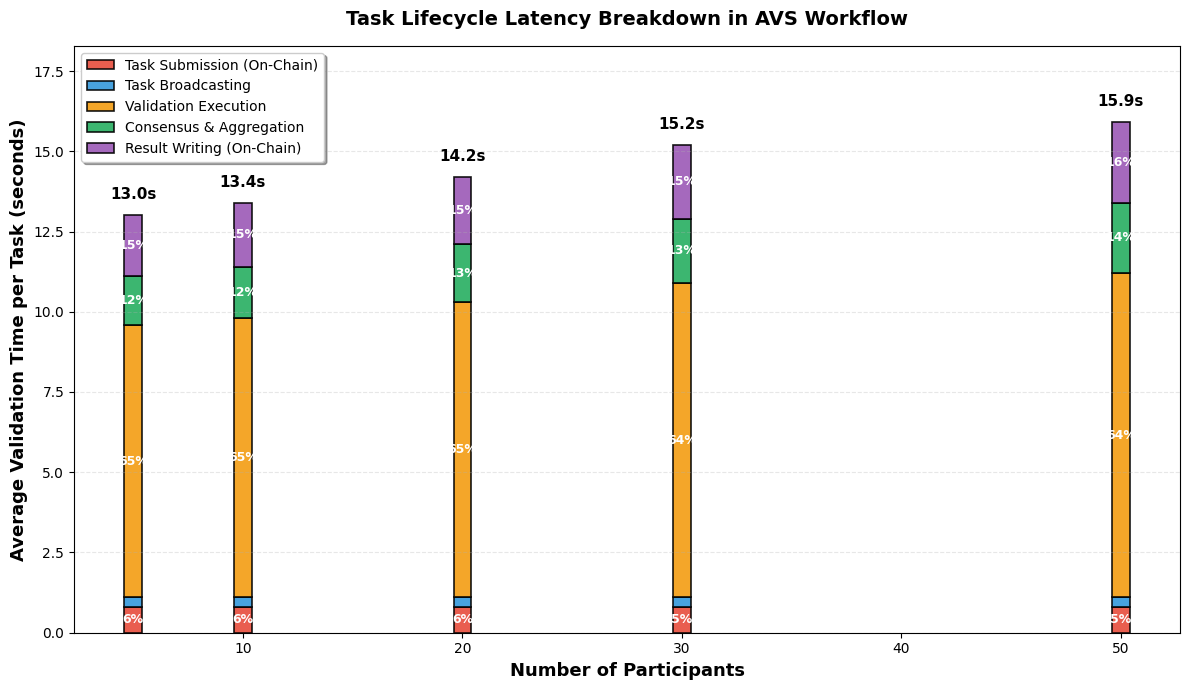

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Puoi estrarre questi dati dai log AVS o misurare manualmente
configs = [5, 10, 20, 30, 50]

# Tempi per fase (in secondi, MEDIA per task)
# Questi dati li ottieni analizzando i log del tuo AVS
task_submission = [0.8, 0.8, 0.8, 0.8, 0.8]      # TX on-chain (costante)
broadcasting = [0.3, 0.3, 0.3, 0.3, 0.3]         # Aggregator notify
validation_exec = [8.5, 8.7, 9.2, 9.8, 10.1]     # Performer processing (scala leggermente)
consensus = [1.5, 1.6, 1.8, 2.0, 2.2]            # Aggregation time
result_writing = [1.9, 2.0, 2.1, 2.3, 2.5]       # TX on-chain (scala con carico)

# Calcola totale
total_time = [sum(x) for x in zip(task_submission, broadcasting, 
                                   validation_exec, consensus, result_writing)]

fig, ax = plt.subplots(figsize=(12, 7))

# Stacked bars
bottom = np.zeros(len(configs))
phases = [
    ('Task Submission (On-Chain)', task_submission, '#E74C3C'),
    ('Task Broadcasting', broadcasting, '#3498DB'),
    ('Validation Execution', validation_exec, '#F39C12'),
    ('Consensus & Aggregation', consensus, '#27AE60'),
    ('Result Writing (On-Chain)', result_writing, '#9B59B6')
]

for label, times, color in phases:
    bars = ax.bar(configs, times, bottom=bottom, label=label, 
                  color=color, edgecolor='black', linewidth=1.2, alpha=0.9)
    
    # Annotazioni percentuali
    for i, (bar, time) in enumerate(zip(bars, times)):
        height = bar.get_height()
        pct = (time / total_time[i]) * 100
        if pct > 5:  # Mostra solo se > 5%
            ax.text(bar.get_x() + bar.get_width()/2, bottom[i] + height/2,
                   f'{pct:.0f}%', ha='center', va='center', 
                   fontsize=9, fontweight='bold', color='white')
    
    bottom += times

# Total time annotation
for i, n in enumerate(configs):
    ax.text(n, total_time[i] + 0.5, f'{total_time[i]:.1f}s', 
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Participants', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Validation Time per Task (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Task Lifecycle Latency Breakdown in AVS Workflow', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(total_time) * 1.15])

plt.tight_layout()
#plt.savefig('task_latency_breakdown.pdf', dpi=300, bbox_inches='tight')